# Gene-Range Perturbation — Multi-Slide Analysis

In [1]:
%matplotlib inline
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 200,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 17,
    'axes.labelsize': 18,
    'axes.titlesize': 16,
    'xtick.labelsize': 13,
    'ytick.labelsize': 15,
    'legend.fontsize': 15,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

RED_LIGHT = '#FC9272'   # Global logFC
RED_MID   = '#CB181D'   # Cell-type-specific logFC
RED_DARK  = '#67000D'   # Edge swap baseline

# kept for cell-7 boxplots
BLUE   = '#2166AC'
ORANGE = '#D6604D'
GREEN  = '#4DAC26'

TOP_N_PERTURB_VALUES = [10, 20, 50, 100, 200, 500, 1000, 2000]

## 1. Load results across all slides

In [2]:
results_root = 'results/gene_range/'
csvs = sorted(glob.glob(f'{results_root}/*/results.csv'))

dfs = []
for p in csvs:
    sid = int(Path(p).parent.name)
    df = pd.read_csv(p)
    df['slide_id'] = sid
    dfs.append(df)

if not dfs:
    raise FileNotFoundError(f'No results.csv files found under {results_root}/*/. Run perturb_gene_range.py first.')

all_df = pd.concat(dfs, ignore_index=True)
slide_ids = sorted(all_df['slide_id'].unique().tolist())
print(f'Loaded {len(dfs)} slide(s): {slide_ids}')
print(f'Total rows: {len(all_df)}')

# Convenience subsets
sweep_mean    = all_df[(all_df['cell_type'] == 'mean') & all_df['top_n_perturb'].notna()].copy()
baseline_mean = all_df[(all_df['cell_type'] == 'mean') & all_df['top_n_perturb'].isna()].copy()
ct_at_200     = all_df[(all_df['top_n_perturb'] == 200) & (all_df['cell_type'] != 'mean')].copy()
ct_baseline   = all_df[all_df['top_n_perturb'].isna() & (all_df['cell_type'] != 'mean')].copy()

sweep_mean['top_n_perturb'] = sweep_mean['top_n_perturb'].astype(int)

Loaded 6 slide(s): [120, 210, 221, 231, 232, 242]
Total rows: 1007


## 2. Summary plot with CI across slides

In [3]:
all_df.sort_values("spearman_r")

,pearson_r,spearman_r,precision,direction_match,direction_match_k,edistance,edistance_local,rmse_log1p,rmse_logfc,strategy,cell_type,top_n_perturb,slide_id
511,-0.397087,-0.538439,0.24,0.083333,0.02,11.676069,6.911985,2087.479736,3.049397,ctspec,Smooth_muscle,2000.0,221
520,-0.522453,-0.530948,0.32,0.062500,0.02,12.147269,7.419068,2096.642090,3.411130,global,Smooth_muscle,3000.0,221
514,-0.616755,-0.529508,0.16,0.000000,0.00,8.201765,5.120476,295.317383,2.400474,global,B_cell,3000.0,221
529,-0.458675,-0.513277,0.26,0.076923,0.02,10.970799,6.499776,2075.927246,2.763443,ctspec,Smooth_muscle,3000.0,221
510,-0.536607,-0.492341,0.10,0.000000,0.00,8.889129,5.321471,1379.084961,2.509030,ctspec,Plasma_cell,2000.0,221
...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0.994516,0.975222,0.82,1.000000,0.82,0.397926,0.424751,31103.824219,0.315725,ctspec,Epithelial,50.0,232
781,0.995632,0.977623,0.88,1.000000,0.88,0.507698,0.402761,30970.130859,0.459106,ctspec,Epithelial,500.0,232
749,0.995533,0.977719,0.84,1.000000,0.84,0.331620,0.380311,31069.302734,0.286496,ctspec,Epithelial,100.0,232
685,0.996823,0.980120,0.88,1.000000,0.88,0.312147,0.281685,31027.212891,0.330180,edge_swap,Epithelial,NaN,232


In [4]:
all_df['slide_id'].unique()

array([120, 210, 221, 231, 232, 242])

In [5]:
sweep_mean

,pearson_r,spearman_r,precision,direction_match,direction_match_k,edistance,edistance_local,rmse_log1p,rmse_logfc,strategy,cell_type,top_n_perturb,slide_id
17,0.828422,0.744874,0.4250,0.975568,0.4150,2.534487,1.697086,81085.142822,1.021063,global,mean,10,120
26,0.832852,0.762581,0.4125,0.975553,0.4025,3.173295,1.943682,81113.652817,1.173707,ctspec,mean,10,120
35,0.758081,0.666267,0.3325,0.962798,0.3225,2.148393,1.564307,81042.985413,0.975545,global,mean,20,120
44,0.839251,0.761645,0.4200,0.980800,0.4125,2.601632,1.631594,81093.516129,1.066114,ctspec,mean,20,120
53,0.790186,0.707983,0.3600,0.975446,0.3525,2.019475,1.444519,81027.166306,0.933904,global,mean,50,120
...,...,...,...,...,...,...,...,...,...,...,...,...,...
970,0.708965,0.614466,0.4600,0.939369,0.4350,1.822925,1.603330,9147.831051,1.272328,ctspec,mean,1000,242
979,0.923883,0.740852,0.4900,1.000000,0.4900,2.941314,2.910935,9471.975090,1.073357,global,mean,2000,242
988,0.571276,0.542749,0.3425,0.900893,0.3100,NaN,NaN,NaN,1.498973,ctspec,mean,2000,242
997,0.790210,0.625666,0.3525,0.966768,0.3425,NaN,NaN,NaN,1.198995,global,mean,3000,242


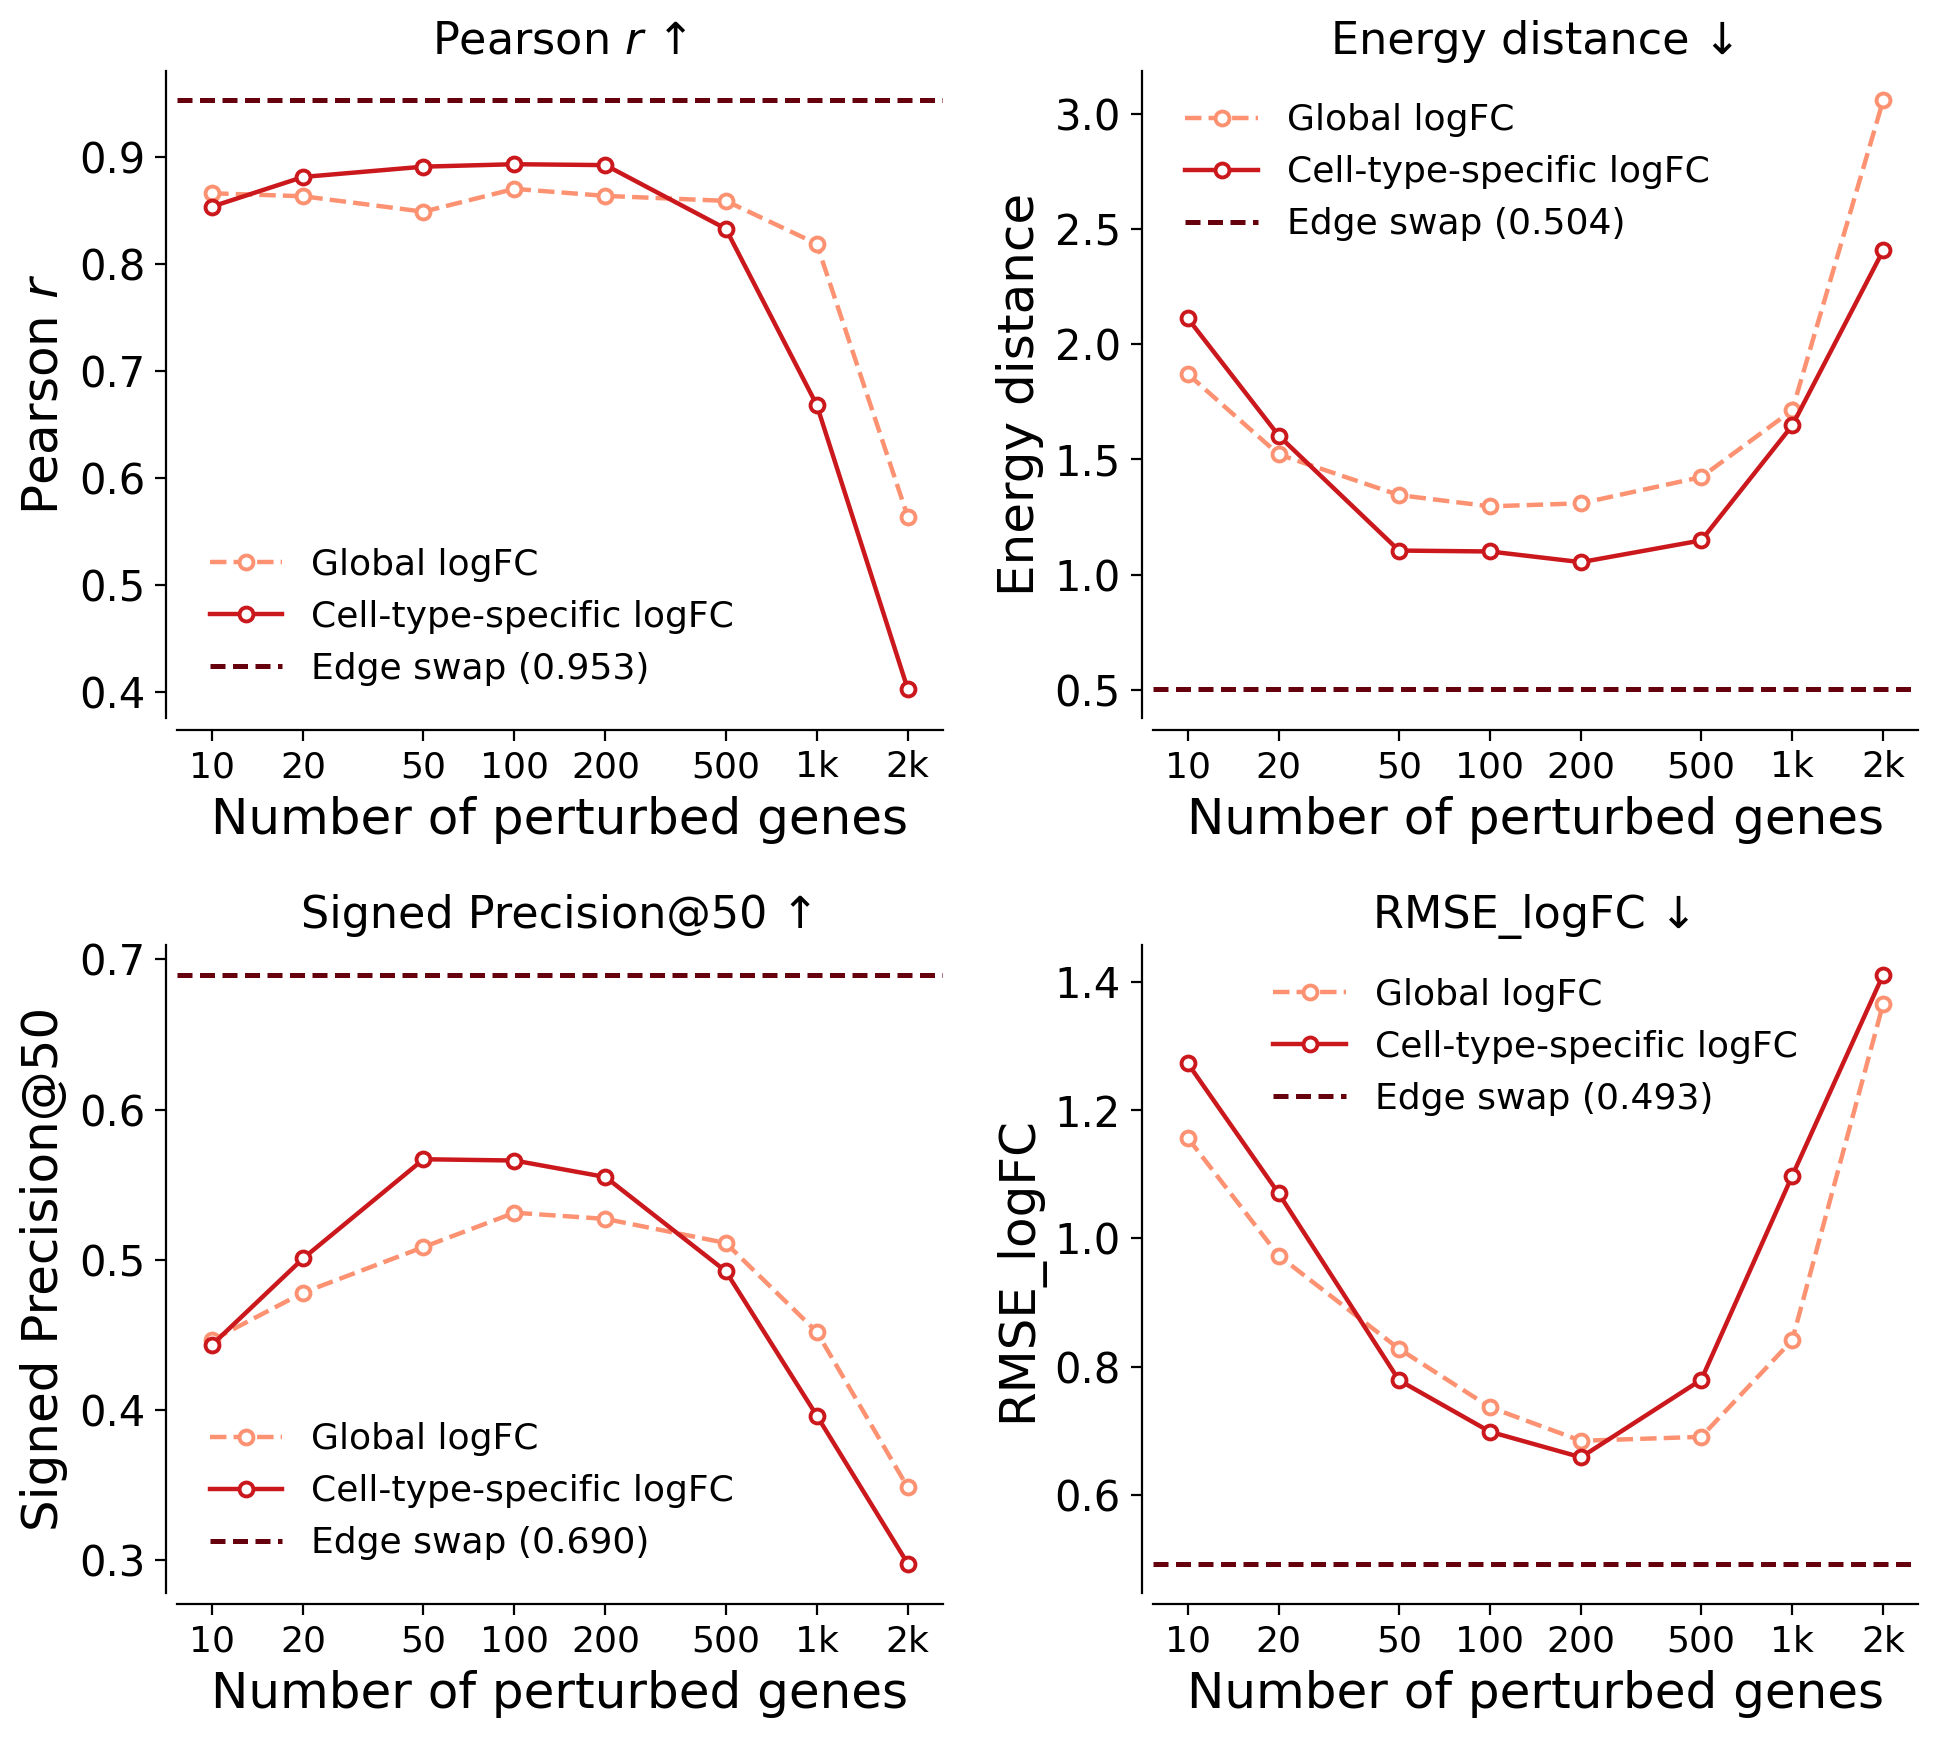

In [ ]:
metrics_spec = [
    ('pearson_r',       'Pearson $r$',             True),
    ('edistance_local', 'Energy distance',   False),
    ('direction_match_k',       'Signed Precision@50',             True),
    ('rmse_logfc',      'RMSE_logFC',               False),
]

TICK_LABELS = ['10', '20', '50', '100', '200', '500', '1k', '2k'] # , '3k'

ncols = 2
nrows = -(-len(metrics_spec) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5.0, nrows * 4.5))
axes = axes.flatten()

for i, (metric, ylabel, higher_better) in enumerate(metrics_spec):
    ax = axes[i]
    arrow = ' ↑' if higher_better else ' ↓'

    for strategy, color, ls, label in [
        ('global', RED_LIGHT, '--', 'Global logFC'),
        ('ctspec', RED_MID,   '-',  'Cell-type-specific logFC'),
    ]:
        sub = sweep_mean[sweep_mean['strategy'] == strategy]
        grp = sub.groupby('top_n_perturb')[metric]
        means = grp.mean().reindex(TOP_N_PERTURB_VALUES)
        stds  = grp.std(ddof=1).reindex(TOP_N_PERTURB_VALUES).fillna(0)
        x = means.index.tolist()

        ax.plot(x, means, color=color, ls=ls, lw=1.6,
                marker='o', ms=5, markerfacecolor='white', markeredgewidth=1.4,
                label=label, zorder=3)

    # Edge-swap baseline (mean only)
    bl = baseline_mean[baseline_mean['strategy'] == 'edge_swap'][metric]
    bl_mean = bl.mean()
    ax.axhline(bl_mean, color=RED_DARK, ls=(0, (3, 1.5)), lw=1.8,
               label=f'Edge swap ({bl_mean:.3f})', zorder=2)

    ax.set_xscale('log')
    ax.set_xticks(TOP_N_PERTURB_VALUES)
    ax.set_xticklabels(TICK_LABELS, rotation=45, ha='right')
    ax.xaxis.set_minor_locator(ticker.NullLocator())
    ax.set_xlabel('Number of perturbed genes')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel + arrow)
    ax.spines['left'].set_position(('outward', 4))
    ax.spines['bottom'].set_position(('outward', 4))
    ax.legend(frameon=False, handlelength=2.0, fontsize=13)

for j in range(len(metrics_spec), len(axes)):
    axes[j].set_visible(False)

# fig.suptitle(f'Slides: {slide_ids}', fontsize=11, y=1.01)
fig.tight_layout()
plt.savefig('convergence.png', bbox_inches='tight')
plt.show()

In [12]:
metrics = [m for m, _, _ in metrics_spec]

# Per-(strategy, top_n) aggregation — one row per point on the plot
agg = (
    sweep_mean[sweep_mean['strategy'].isin(['global', 'ctspec'])]
    .groupby(['strategy', 'top_n_perturb'])[metrics]
    .agg(['mean', 'std'])
    .reindex(TOP_N_PERTURB_VALUES, level='top_n_perturb')
)

# Edge-swap baseline (one number per metric — the dashed horizontal line)
baseline = (
    baseline_mean[baseline_mean['strategy'] == 'edge_swap'][metrics]
    .mean()
    .rename('edge_swap_mean')
)

In [13]:
agg

pearson_r           edistance_local            \
                            mean       std            mean       std   
strategy top_n_perturb                                                 
ctspec   10             0.853353  0.063200        2.112066  1.126318   
         20             0.881010  0.059893        1.602782  0.947680   
         50             0.890615  0.075570        1.104291  0.482625   
         100            0.892906  0.081621        1.100269  0.536776   
         200            0.892063  0.080982        1.053948  0.442983   
         500            0.832638  0.134955        1.148249  0.651044   
         1000           0.668048  0.344479        1.646900  1.193518   
         2000           0.402582  0.410653        2.406539  2.110509   
global   10             0.865740  0.031408        1.870524  0.877844   
         20             0.862962  0.075281        1.521245  0.879705   
         50             0.848534  0.120369        1.345010  0.451166   
         100            0.869882  0.113560        1.296122  0.399928   
         200            0.863305  0.123354        1.309313  0.425243   
         500            0.858675  0.117895        1.422906  0.563956   
         1000           0.818524  0.115579        1.712968  0.712152   
         2000           0.563698  0.405182        3.058524  1.895441   

                       direction_match_k           rmse_logfc            
                                    mean       std       mean       std  
strategy top_n_perturb                                                   
ctspec   10                     0.443571  0.066684   1.272985  0.424092  
         20                     0.500999  0.078026   1.069957  0.399066  
         50                     0.566938  0.085723   0.778866  0.246080  
         100                    0.566085  0.106594   0.698571  0.220129  
         200                    0.555099  0.105347   0.658731  0.163762  
         500                    0.492467  0.150202   0.779500  0.393386  
         1000                   0.396422  0.180078   1.097582  0.729706  
         2000                   0.297976  0.187601   1.411135  0.758427  
global   10                     0.446581  0.047306   1.156672  0.383727  
         20                     0.478188  0.092707   0.973127  0.379684  
         50                     0.508485  0.117563   0.827853  0.252444  
         100                    0.531369  0.096840   0.736758  0.138517  
         200                    0.527242  0.097331   0.684430  0.105192  
         500                    0.511230  0.113265   0.690602  0.119754  
         1000                   0.452103  0.156086   0.841310  0.361123  
         2000                   0.348664  0.191219   1.365956  0.852872

## 3. Per-cell-type boxplots at 200 genes

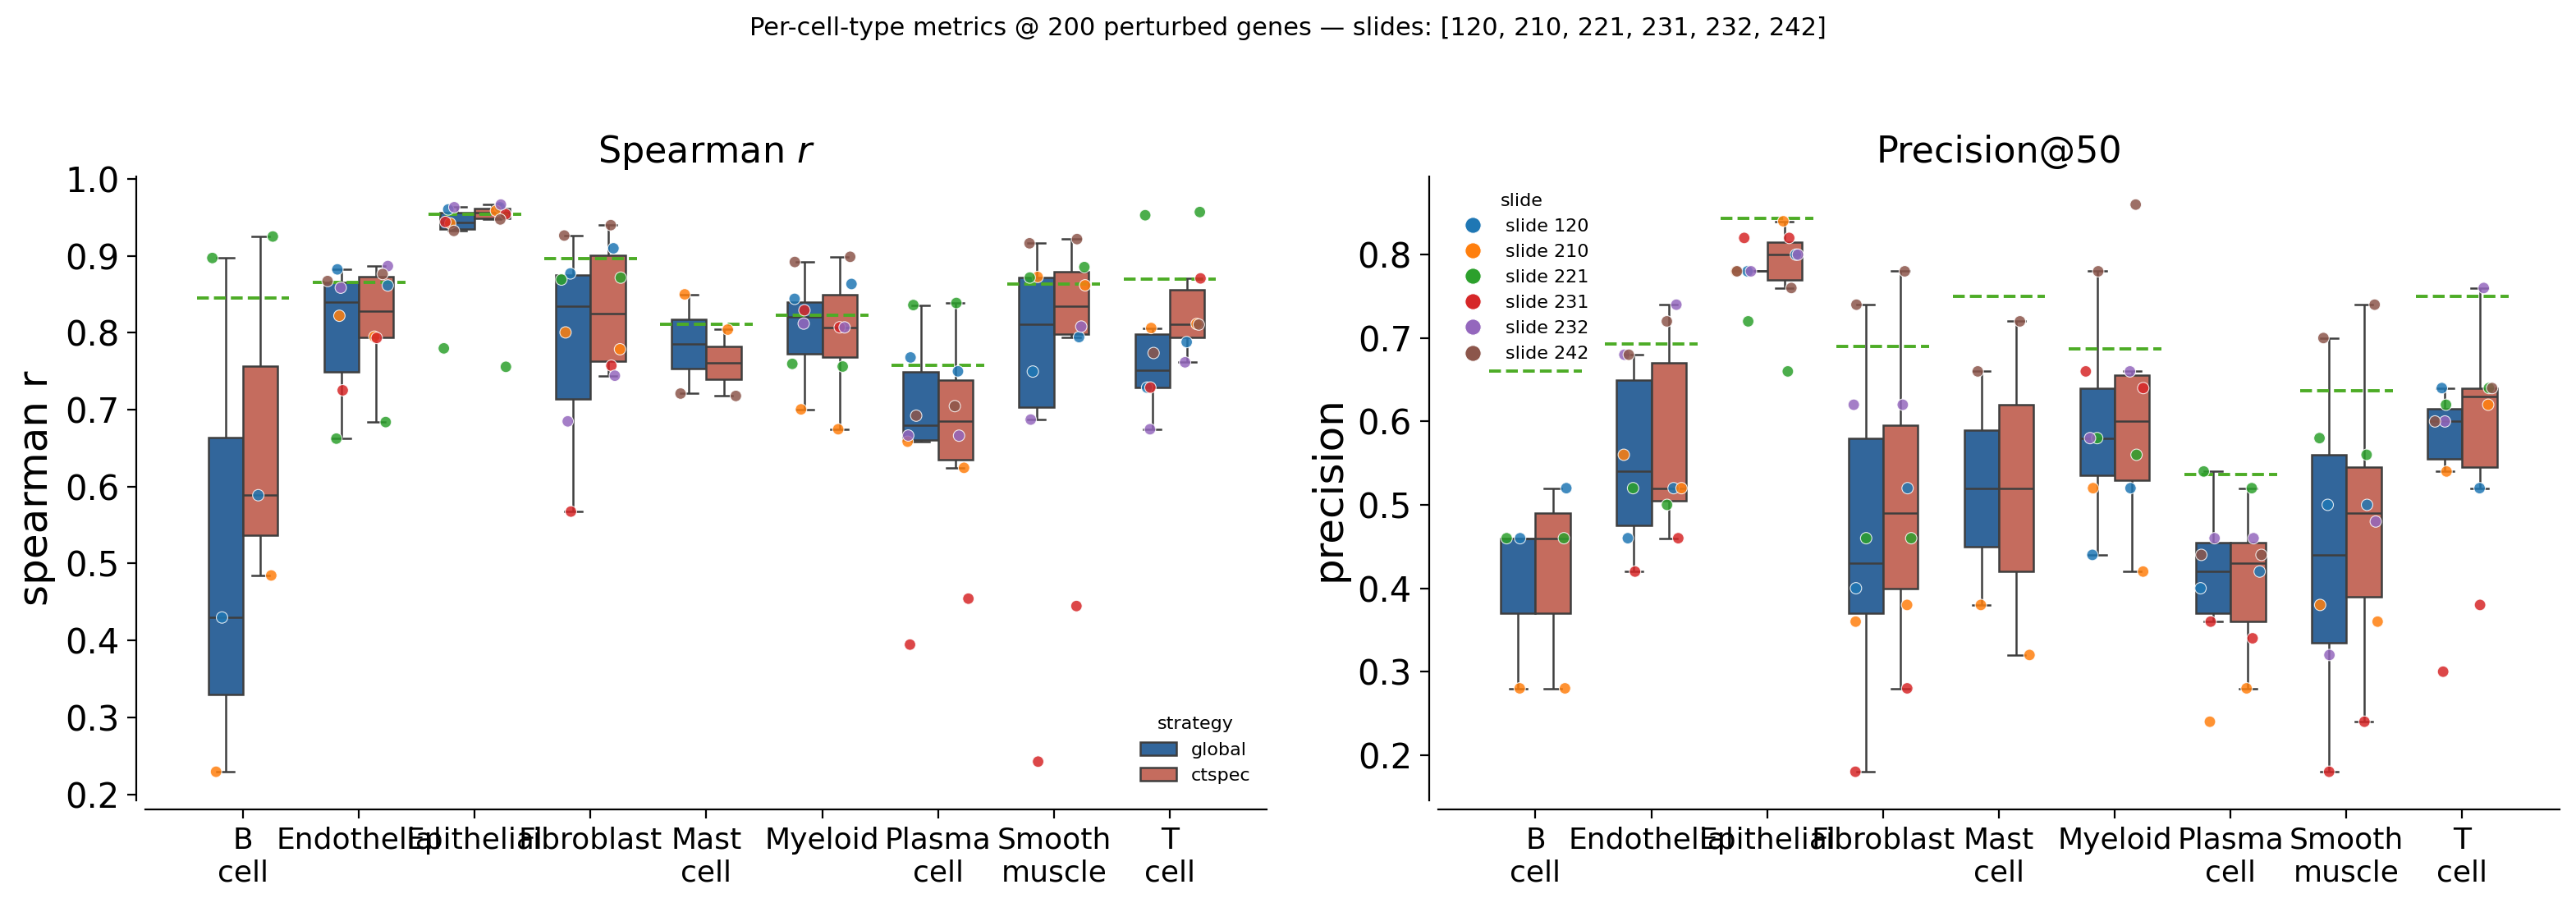

In [9]:
import numpy as np

cell_types = sorted(ct_at_200['cell_type'].unique().tolist())
strategies = ['global', 'ctspec']
strategy_palette = {'global': BLUE, 'ctspec': ORANGE}

plot_specs = [
    ('spearman_r', r'Spearman $r$'),
    ('precision',  'Precision@50'),
]

slides = sorted(ct_at_200['slide_id'].unique())
slide_cmap = dict(zip(slides, sns.color_palette('tab10', n_colors=len(slides))))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
rng = np.random.default_rng(0)

for ax, (metric, title) in zip(axes, plot_specs):
    sns.boxplot(
        data=ct_at_200, x='cell_type', y=metric, hue='strategy',
        order=cell_types, hue_order=strategies,
        palette=strategy_palette,
        ax=ax, width=0.6, linewidth=0.9,
        flierprops=dict(marker='', markersize=0),
    )

    # Manual point overlay: offset by strategy (to match dodged boxes), color by slide_id
    for ct_idx, ct in enumerate(cell_types):
        for strat_idx, strat in enumerate(strategies):
            sub = ct_at_200[(ct_at_200['cell_type'] == ct) &
                            (ct_at_200['strategy'] == strat)]
            if len(sub) == 0:
                continue
            offset = -0.2 if strat_idx == 0 else 0.2
            xs = ct_idx + offset + rng.uniform(-0.07, 0.07, len(sub))
            colors = [slide_cmap[s] for s in sub['slide_id']]
            ax.scatter(xs, sub[metric].values, c=colors,
                       s=25, alpha=0.85, zorder=4,
                       edgecolors='white', linewidths=0.4)

    # Per-cell-type edge-swap baseline (spans both strategy boxes)
    bl_sub = ct_baseline[ct_baseline['strategy'] == 'edge_swap']
    for xi, ct in enumerate(cell_types):
        ct_bl = bl_sub[bl_sub['cell_type'] == ct][metric]
        if len(ct_bl) > 0:
            ax.hlines(ct_bl.mean(), xi - 0.4, xi + 0.4,
                      colors=GREEN, linewidths=1.4, linestyles='--', zorder=3)

    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel(metric.replace('_', ' '))
    ax.set_xticks(range(len(cell_types)))
    ax.set_xticklabels([ct.replace('_', '\n') for ct in cell_types],
                       rotation=0, fontsize=9)
    ax.spines['left'].set_position(('outward', 4))
    ax.spines['bottom'].set_position(('outward', 4))

    # Legends: strategy on the left panel, slide_id on the right panel
    if ax is axes[0]:
        strat_handles, strat_labels = ax.get_legend_handles_labels()
        ax.legend(strat_handles, strat_labels, title='strategy',
                  loc='best', frameon=False, fontsize=8, title_fontsize=8)
    else:
        if ax.get_legend():
            ax.get_legend().remove()
        slide_handles = [plt.Line2D([0], [0], marker='o', color='w',
                                    markerfacecolor=slide_cmap[s],
                                    markeredgecolor='white', markeredgewidth=0.4,
                                    markersize=7, label=f'slide {s}')
                         for s in slides]
        ax.legend(handles=slide_handles, title='slide',
                  loc='best', frameon=False, fontsize=8, title_fontsize=8)

fig.suptitle(f'Per-cell-type metrics @ 200 perturbed genes — slides: {slide_ids}',
             fontsize=11, y=1.01)
fig.tight_layout()
plt.show()